# Browser History + Google Subscriber Info: Initial Data Audit

In this notebook, I am exploring whether patterns in browser history can be analyzed alongside account-level information from Google's SubscriberInfo export. Both of these data sources were obtained from a personal Google data export. 

The first goal is to load both datasets and inspect their structure before deciding which algorithms are appropriate. At this stage, I am not trying to model behavior yet. I am simply determining:

1. what fields are available,
2. which fields are clean enough to use,
3. whether the two datasets can meaningfully complement one another.

# Step 1: Load and Inspect Data
### Browser history parquet
1. Load packages and define file paths. 
2. Inspect the schema.
3. Check for missing values and unique values

In [84]:
from pathlib import Path
import sys
import importlib
import pandas as pd
import numpy as np
import re
from bs4 import BeautifulSoup
from import_json import load_json_to_df

CODE_DIR = Path(r"C:/Users/User/OneDrive/Documents/Personal_Projects/sgillihan.github.io/projects/proxy-data-research/code")
sys.path.insert(0, str(CODE_DIR))

import import_json
importlib.reload(import_json)

export_to_parquet = import_json.export_to_parquet

SOURCE_JSON = Path(r"C:/Users/User/OneDrive/Documents/CSPB3112/Datasets/Personal_Google/Takeout/Chrome/History.json")
OUTPUT_DIR = Path(r"C:/Users/User/OneDrive/Documents/CSPB3112/Datasets/Personal_Google/chrome_hist_parquets")
BROWSER_HISTORY_PARQUET = OUTPUT_DIR / "browser_history.parquet"

# Export separate parquet files
paths = export_to_parquet(SOURCE_JSON, OUTPUT_DIR)
display(paths)

# Load browser history parquet
browser_hist = pd.read_parquet(BROWSER_HISTORY_PARQUET)

print("Shape:", browser_hist.shape)
print("\nColumns:")
print(browser_hist.columns.tolist())
print("\nDtypes:")
print(browser_hist.dtypes)
#display(browser_hist.head())

# Safe unique-count audit
safe_n_unique = {}
for col in browser_hist.columns:
    try:
        n = browser_hist[col].nunique(dropna=True)
        safe_n_unique[col] = n
        print(f"{col}: OK ({n} unique)")
    except Exception as e:
        safe_n_unique[col] = f"ERROR: {type(e).__name__}"
        print(f"{col}: ERROR -> {type(e).__name__}: {e}")

# Basic audit table
audit_table = pd.DataFrame({
    "dtype": browser_hist.dtypes.astype(str),
    "non_null_count": browser_hist.notna().sum(),
    "null_count": browser_hist.isna().sum(),
    "null_percentage": (browser_hist.isna().mean() * 100).round(2),
    "n_unique": pd.Series(safe_n_unique)
}).sort_values("null_percentage", ascending=False)

#display(audit_table)

Browser History: wrote 41,707 rows x 6 cols -> C:\Users\User\OneDrive\Documents\CSPB3112\Datasets\Personal_Google\chrome_hist_parquets\browser_history.parquet
Typed Url: wrote 0 rows x 0 cols -> C:\Users\User\OneDrive\Documents\CSPB3112\Datasets\Personal_Google\chrome_hist_parquets\typed_url.parquet
Session: wrote 6 rows x 15 cols -> C:\Users\User\OneDrive\Documents\CSPB3112\Datasets\Personal_Google\chrome_hist_parquets\session.parquet
Shared Tab Group: wrote 0 rows x 0 cols -> C:\Users\User\OneDrive\Documents\CSPB3112\Datasets\Personal_Google\chrome_hist_parquets\shared_tab_group.parquet


{'Browser History': WindowsPath('C:/Users/User/OneDrive/Documents/CSPB3112/Datasets/Personal_Google/chrome_hist_parquets/browser_history.parquet'),
 'Typed Url': WindowsPath('C:/Users/User/OneDrive/Documents/CSPB3112/Datasets/Personal_Google/chrome_hist_parquets/typed_url.parquet'),
 'Session': WindowsPath('C:/Users/User/OneDrive/Documents/CSPB3112/Datasets/Personal_Google/chrome_hist_parquets/session.parquet'),
 'Shared Tab Group': WindowsPath('C:/Users/User/OneDrive/Documents/CSPB3112/Datasets/Personal_Google/chrome_hist_parquets/shared_tab_group.parquet')}

Shape: (41707, 6)

Columns:
['favicon_url', 'page_transition_qualifier', 'title', 'url', 'time_usec', 'client_id']

Dtypes:
favicon_url                  object
page_transition_qualifier    object
title                        object
url                          object
time_usec                     int64
client_id                    object
dtype: object
favicon_url: OK (1598 unique)
page_transition_qualifier: OK (1 unique)
title: OK (11242 unique)
url: OK (19263 unique)
time_usec: OK (41707 unique)
client_id: OK (2 unique)


### Subscriber Data HTML
1. Load and inspect HTML file
2. Parse the file using BeautifulSoup.
3. Check for key-value style fields in the HTML

In [85]:
SUBSCRIBER_INFO_PATH = Path("C:/Users/User/OneDrive/Documents/CSPB3112/Datasets/Personal_Google/Takeout/Google Account/sgillihan.SubscriberInfo.html")
html_text = SUBSCRIBER_INFO_PATH.read_text(encoding="utf-8", errors="ignore")

print("HTML length:", len(html_text))
#print("\nFirst 500 characters:\n")
#print(html_text[80:100])

soup = BeautifulSoup(html_text, "html.parser")
# get visible text in a rough cleaned form
text = soup.get_text(separator="\n")
lines = [line.strip() for line in text.splitlines()]
lines = [line for line in lines if line]
#print("Sample lines:\n")
#for line in lines[80:100]:
#    print(line)

# Very simple heuristic for inspecting likely key/value adjacent text
#for i, line in enumerate(lines[:200]):
#    if i < len(lines) - 1:
#        print(f"{i:03d}: {line}  -->  {lines[i+1]}")

HTML length: 255271


# Step 2: Parse browser history and Google account activity separately

The Google HTML export contains two distinct types of information:

1. account-level metadata at the top of the file,
2. a structured activity table containing timestamped events such as logins.

The focus will be on timestamped activity patterns for this exercise.

1. Clean the browser history data to enable meaningful time tracking
2. Parse the HTML data with header and table separated
3. Parse and clean the activity table

In [86]:
from urllib.parse import urlparse

hist = browser_hist.copy()

hist["datetime_utc"] = pd.to_datetime(hist["time_usec"], unit="us", utc=True, errors="coerce")

def get_domain(url):
    try:
        return urlparse(url).netloc.lower()
    except:
        return np.nan

def get_path(url):
    try:
        return urlparse(url).path
    except:
        return np.nan

def get_scheme(url):
    try:
        return urlparse(url).scheme
    except:
        return np.nan

hist["domain"] = hist["url"].apply(get_domain)
hist["path"] = hist["url"].apply(get_path)
hist["scheme"] = hist["url"].apply(get_scheme)

hist["date"] = hist["datetime_utc"].dt.date
hist["hour_utc"] = hist["datetime_utc"].dt.hour
hist["day_of_week"] = hist["datetime_utc"].dt.day_name()
hist["month"] = hist["datetime_utc"].dt.month
hist["year"] = hist["datetime_utc"].dt.year

#display(hist.head())

In [88]:
header_fields = {}
header_end_idx = None

for i, line in enumerate(lines):
    # stop when we reach the activity table header
    if "Timestamp" in line and "IP Address" in line and "Activity Type" in line:
        header_end_idx = i
        break

    if ":" in line:
        key, value = line.split(":", 1)
        header_fields[key.strip()] = value.strip()

header_df = pd.DataFrame([header_fields])
#display(header_df.T)
#print("Header ends at line index:", header_end_idx)

In [82]:
soup = BeautifulSoup(html_text, "html.parser")

tables = soup.find_all("table")
print("Number of tables found:", len(tables))

# Try reading all HTML tables with pandas
html_tables = pd.read_html(html_text)

print("Number of tables parsed by pandas:", len(html_tables))
for idx, tbl in enumerate(html_tables):
    print(f"\nTable {idx}: shape={tbl.shape}")
    #display(tbl.head())

Number of tables found: 2
Number of tables parsed by pandas: 2

Table 0: shape=(1, 8)

Table 1: shape=(1612, 8)


C:\Users\User\AppData\Local\Temp\ipykernel_30264\3957159970.py:7: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  html_tables = pd.read_html(html_text)


Identify Table with activity columns and clean it

In [89]:
activity_df = None

for tbl in html_tables:
    cols = [str(c).strip() for c in tbl.columns]
    if {"Timestamp", "IP Address", "Activity Type"}.issubset(set(cols)):
        activity_df = tbl.copy()
        break

if activity_df is None:
    print("No matching activity table found.")
else:
    print("Activity table found.")
    #display(activity_df.head())
    print(activity_df.columns.tolist())

Activity table found.
['Timestamp', 'IP Address', 'Activity Type', 'Interactive', 'Initiating Service', 'Geo', 'Raw User Agents', 'Challenges (timestamp, outcome, dusi)']


In [90]:
if activity_df is not None:
    activity_df = activity_df.copy()

    # Standardize column names
    activity_df.columns = (
        activity_df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
    )

    # Parse timestamps
    if "timestamp" in activity_df.columns:
        activity_df["timestamp_utc"] = pd.to_datetime(activity_df["timestamp"], utc=True, errors="coerce")

    # Normalize interactive flag if present
    if "interactive" in activity_df.columns:
        activity_df["interactive_bool"] = (
            activity_df["interactive"]
            .astype(str)
            .str.strip()
            .str.lower()
            .map({"true": True, "false": False})
        )

    # Split geo if possible
    if "geo" in activity_df.columns:
        geo_parts = activity_df["geo"].astype(str).str.split(",", expand=True)
        if geo_parts.shape[1] >= 3:
            activity_df["geo_country"] = geo_parts[0].str.strip()
            activity_df["geo_state"] = geo_parts[1].str.strip()
            activity_df["geo_city"] = geo_parts[2].str.strip()

    # Time features
    if "timestamp_utc" in activity_df.columns:
        activity_df["date"] = activity_df["timestamp_utc"].dt.date
        activity_df["hour_utc"] = activity_df["timestamp_utc"].dt.hour
        activity_df["day_of_week"] = activity_df["timestamp_utc"].dt.day_name()

    #display(activity_df.head())
    print("Rows:", len(activity_df))
    if "timestamp_utc" in activity_df.columns:
        print("Date range:", activity_df["timestamp_utc"].min(), "to", activity_df["timestamp_utc"].max())

Rows: 1612
Date range: 2025-05-15 19:45:17+00:00 to 2026-02-10 02:11:12+00:00


Summarize Activity Data:

In [61]:
if activity_df is not None:
    if "activity_type" in activity_df.columns:
        display(activity_df["activity_type"].value_counts(dropna=False).rename("count"))

    if "initiating_service" in activity_df.columns:
        display(activity_df["initiating_service"].value_counts(dropna=False).head(20).rename("count"))

    if "geo_city" in activity_df.columns:
        display(activity_df["geo_city"].value_counts(dropna=False).head(20).rename("count"))

activity_type
Login    1612
Name: count, dtype: int64

initiating_service
NaN    1612
Name: count, dtype: int64

geo_city
Dakota Ridge       1191
Denver              209
Portland             32
Houston              31
Highlands Ranch      27
Seattle              21
Aurora               20
None                 19
Boise                16
Lakewood             12
Corvallis             8
Coeur d'Alene         6
Ken Caryl             5
Tangent               4
Fort Worth            4
Los Angeles           2
Cheyenne              2
St. Louis             1
Dallas                1
Chicago               1
Name: count, dtype: int64

Compare Activity coverage to Browser History Coverage

In [62]:
browser_min = hist["datetime_utc"].min()
browser_max = hist["datetime_utc"].max()

activity_min = activity_df["timestamp_utc"].min() if activity_df is not None and "timestamp_utc" in activity_df.columns else pd.NaT
activity_max = activity_df["timestamp_utc"].max() if activity_df is not None and "timestamp_utc" in activity_df.columns else pd.NaT

coverage = pd.DataFrame({
    "dataset": ["browser_history", "google_activity_table"],
    "min_timestamp_utc": [browser_min, activity_min],
    "max_timestamp_utc": [browser_max, activity_max],
    "rows": [len(hist), len(activity_df) if activity_df is not None else 0]
})

display(coverage)

,dataset,min_timestamp_utc,max_timestamp_utc,rows
0,browser_history,2025-02-10 04:13:07.260483+00:00,2026-02-10 02:45:53.390245+00:00,41707
1,google_activity_table,2025-05-15 19:45:17+00:00,2026-02-10 02:11:12+00:00,1612


# Step 3: Temporal pattern analysis

Both datasets have been cleaned enough to support time-based exploration.

The browser history data captures browsing behavior over time, while the Google activity table captures account-related activity events across a partially overlapping period.

The goal of this section is to compare their temporal structure by examining:

1. activity volume over time,
2. activity by hour of day,
3. activity by day of week,
4. whether the two datasets appear to follow similar rhythms.

This is an important intermediate step before session detection, entropy measures, or sequence-based modeling.

In [63]:
# Filter for overlapping date range
overlap_start = max(hist["datetime_utc"].min(), activity_df["timestamp_utc"].min())
overlap_end = min(hist["datetime_utc"].max(), activity_df["timestamp_utc"].max())

hist_overlap = hist[(hist["datetime_utc"] >= overlap_start) & (hist["datetime_utc"] <= overlap_end)].copy()
activity_overlap = activity_df[(activity_df["timestamp_utc"] >= overlap_start) & (activity_df["timestamp_utc"] <= overlap_end)].copy()

print("Overlap start:", overlap_start)
print("Overlap end:", overlap_end)
print("Browser rows in overlap:", len(hist_overlap))
print("Activity rows in overlap:", len(activity_overlap))

Overlap start: 2025-05-15 19:45:17+00:00
Overlap end: 2026-02-10 02:11:12+00:00
Browser rows in overlap: 29067
Activity rows in overlap: 1612


Convert to MST

In [64]:
LOCAL_TZ = "America/Denver"

hist_overlap["datetime_local"] = hist_overlap["datetime_utc"].dt.tz_convert(LOCAL_TZ)
activity_overlap["timestamp_local"] = activity_overlap["timestamp_utc"].dt.tz_convert(LOCAL_TZ)

hist_overlap["date_local"] = hist_overlap["datetime_local"].dt.date
hist_overlap["hour_local"] = hist_overlap["datetime_local"].dt.hour
hist_overlap["day_of_week_local"] = hist_overlap["datetime_local"].dt.day_name()

activity_overlap["date_local"] = activity_overlap["timestamp_local"].dt.date
activity_overlap["hour_local"] = activity_overlap["timestamp_local"].dt.hour
activity_overlap["day_of_week_local"] = activity_overlap["timestamp_local"].dt.day_name()

Compare daily activity volume over time

In [65]:
browser_daily = (
    hist_overlap.groupby("date_local")
    .size()
    .rename("browser_events")
    .reset_index()
)

activity_daily = (
    activity_overlap.groupby("date_local")
    .size()
    .rename("google_activity_events")
    .reset_index()
)

daily_compare = browser_daily.merge(activity_daily, on="date_local", how="outer").sort_values("date_local")
daily_compare = daily_compare.fillna(0)

display(daily_compare.head())
display(daily_compare.tail())

,date_local,browser_events,google_activity_events
0,2025-05-15,5.0,1.0
1,2025-05-16,138.0,4.0
2,2025-05-17,95.0,2.0
3,2025-05-18,122.0,3.0
4,2025-05-19,298.0,2.0


,date_local,browser_events,google_activity_events
265,2026-02-05,618.0,4.0
266,2026-02-06,258.0,5.0
267,2026-02-07,339.0,7.0
268,2026-02-08,196.0,4.0
269,2026-02-09,69.0,8.0


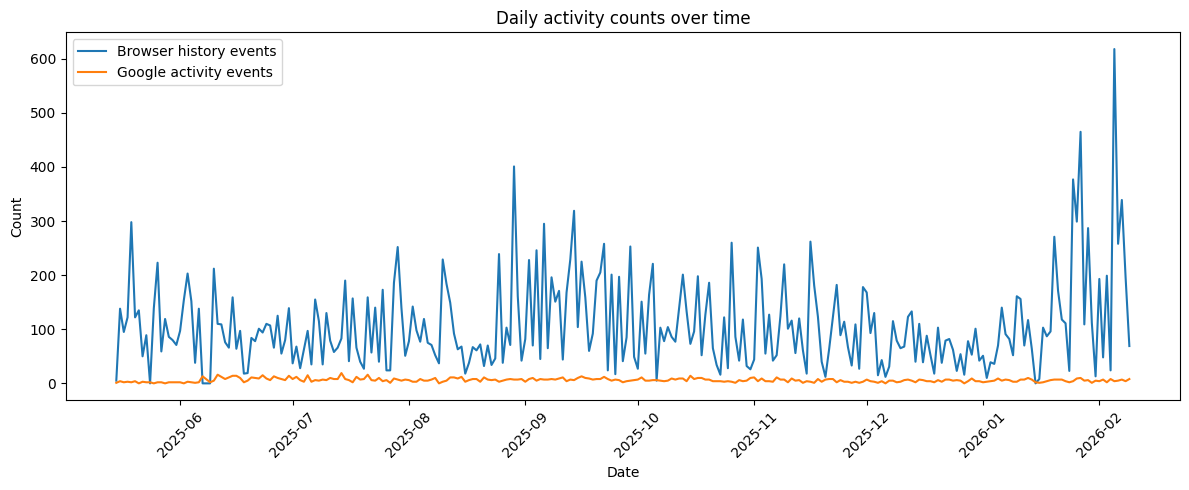

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(daily_compare["date_local"], daily_compare["browser_events"], label="Browser history events")
plt.plot(daily_compare["date_local"], daily_compare["google_activity_events"], label="Google activity events")
plt.title("Daily activity counts over time")
plt.xlabel("Date")
plt.ylabel("Count")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Compare 7 day rolling averages over time

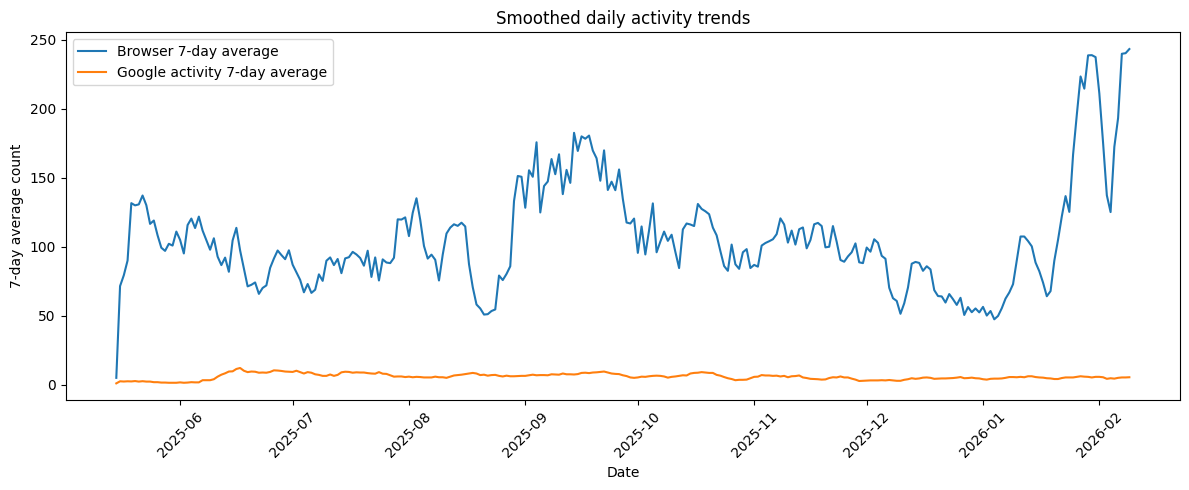

In [67]:
daily_compare["browser_7d_avg"] = daily_compare["browser_events"].rolling(7, min_periods=1).mean()
daily_compare["google_7d_avg"] = daily_compare["google_activity_events"].rolling(7, min_periods=1).mean()

plt.figure(figsize=(12, 5))
plt.plot(daily_compare["date_local"], daily_compare["browser_7d_avg"], label="Browser 7-day average")
plt.plot(daily_compare["date_local"], daily_compare["google_7d_avg"], label="Google activity 7-day average")
plt.title("Smoothed daily activity trends")
plt.xlabel("Date")
plt.ylabel("7-day average count")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Compare activity by hour of day. Hourly distributions can reveal proxy data such as employment type.

In [68]:
hour_order = list(range(24))

browser_hourly = (
    hist_overlap["hour_local"]
    .value_counts()
    .reindex(hour_order, fill_value=0)
    .rename_axis("hour_local")
    .reset_index(name="browser_count")
)

activity_hourly = (
    activity_overlap["hour_local"]
    .value_counts()
    .reindex(hour_order, fill_value=0)
    .rename_axis("hour_local")
    .reset_index(name="google_activity_count")
)

hourly_compare = browser_hourly.merge(activity_hourly, on="hour_local", how="outer").fillna(0)
display(hourly_compare)

,hour_local,browser_count,google_activity_count
0,0,177,31
1,1,28,32
2,2,34,21
3,3,87,3
4,4,190,6
5,5,469,42
6,6,1368,91
7,7,1608,132
8,8,1509,101
9,9,1438,118


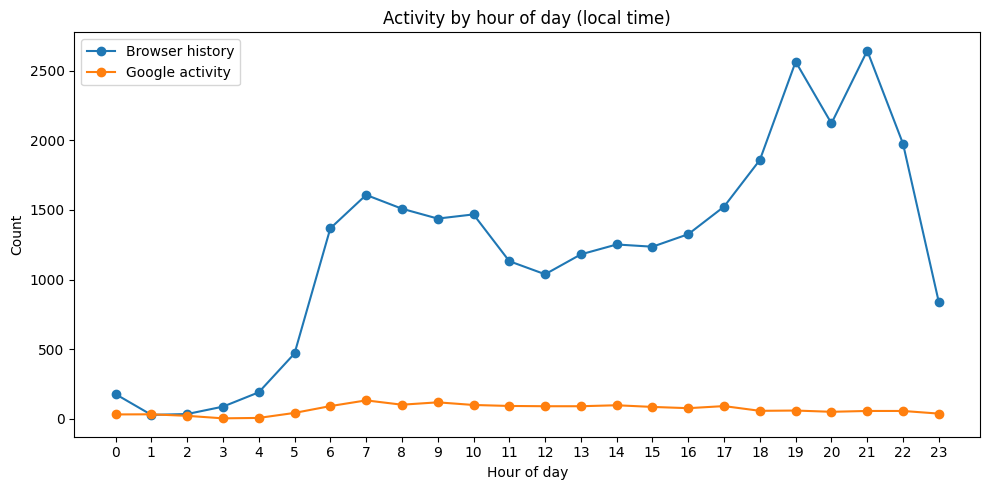

In [69]:
plt.figure(figsize=(10, 5))
plt.plot(hourly_compare["hour_local"], hourly_compare["browser_count"], marker="o", label="Browser history")
plt.plot(hourly_compare["hour_local"], hourly_compare["google_activity_count"], marker="o", label="Google activity")
plt.title("Activity by hour of day (local time)")
plt.xlabel("Hour of day")
plt.ylabel("Count")
plt.xticks(range(24))
plt.legend()
plt.tight_layout()
plt.show()

Normalize hourly patterns

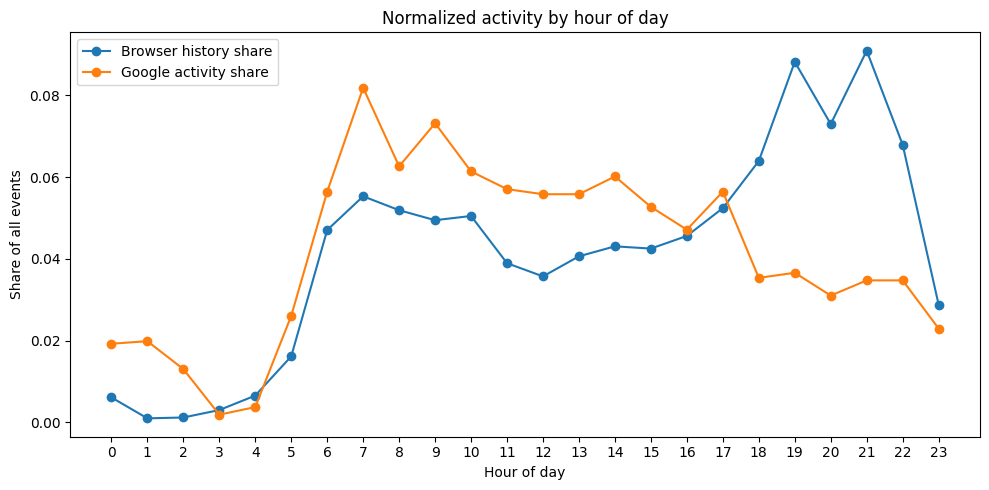

In [70]:
hourly_compare["browser_share"] = hourly_compare["browser_count"] / hourly_compare["browser_count"].sum()
hourly_compare["google_share"] = hourly_compare["google_activity_count"] / hourly_compare["google_activity_count"].sum()

plt.figure(figsize=(10, 5))
plt.plot(hourly_compare["hour_local"], hourly_compare["browser_share"], marker="o", label="Browser history share")
plt.plot(hourly_compare["hour_local"], hourly_compare["google_share"], marker="o", label="Google activity share")
plt.title("Normalized activity by hour of day")
plt.xlabel("Hour of day")
plt.ylabel("Share of all events")
plt.xticks(range(24))
plt.legend()
plt.tight_layout()
plt.show()

Explore Activity by day of week

In [76]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

hist_overlap["day_of_week_local"] = pd.Categorical(
    hist_overlap["day_of_week_local"],
    categories=day_order,
    ordered=True
)

activity_overlap["day_of_week_local"] = pd.Categorical(
    activity_overlap["day_of_week_local"],
    categories=day_order,
    ordered=True
)

browser_dow = (
    hist_overlap.groupby("day_of_week_local", observed=False)
    .size()
    .reset_index(name="browser_count")
)

activity_dow = (
    activity_overlap.groupby("day_of_week_local", observed=False)
    .size()
    .reset_index(name="google_activity_count")
)

dow_compare = (
    browser_dow.merge(activity_dow, on="day_of_week_local", how="outer")
    .sort_values("day_of_week_local")
)

dow_compare["browser_count"] = dow_compare["browser_count"].fillna(0)
dow_compare["google_activity_count"] = dow_compare["google_activity_count"].fillna(0)

display(dow_compare)

,day_of_week_local,browser_count,google_activity_count
0,Monday,5234,283
1,Tuesday,4835,238
2,Wednesday,3473,222
3,Thursday,3303,229
4,Friday,3843,230
5,Saturday,3330,218
6,Sunday,5049,192


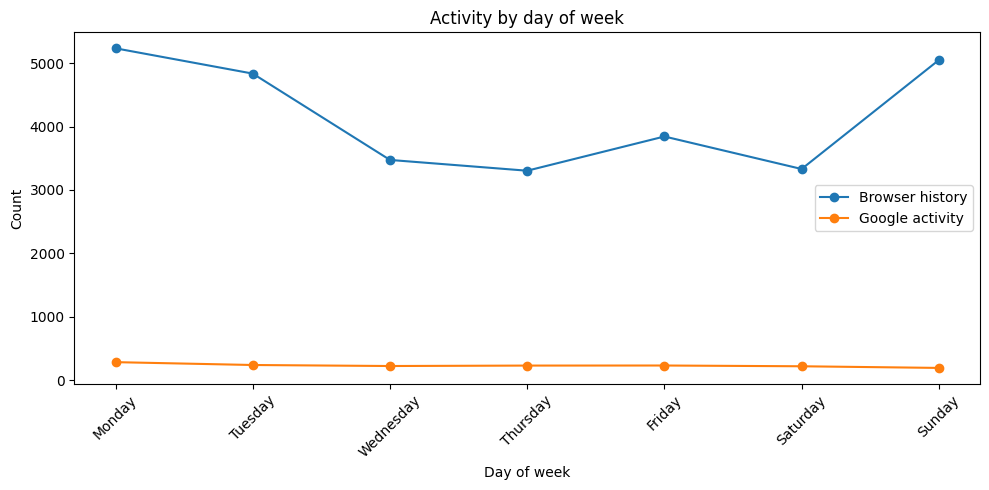

In [78]:
plt.figure(figsize=(10, 5))
plt.plot(dow_compare["day_of_week_local"], dow_compare["browser_count"], marker="o", label="Browser history")
plt.plot(dow_compare["day_of_week_local"], dow_compare["google_activity_count"], marker="o", label="Google activity")
plt.title("Activity by day of week")
plt.xlabel("Day of week")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

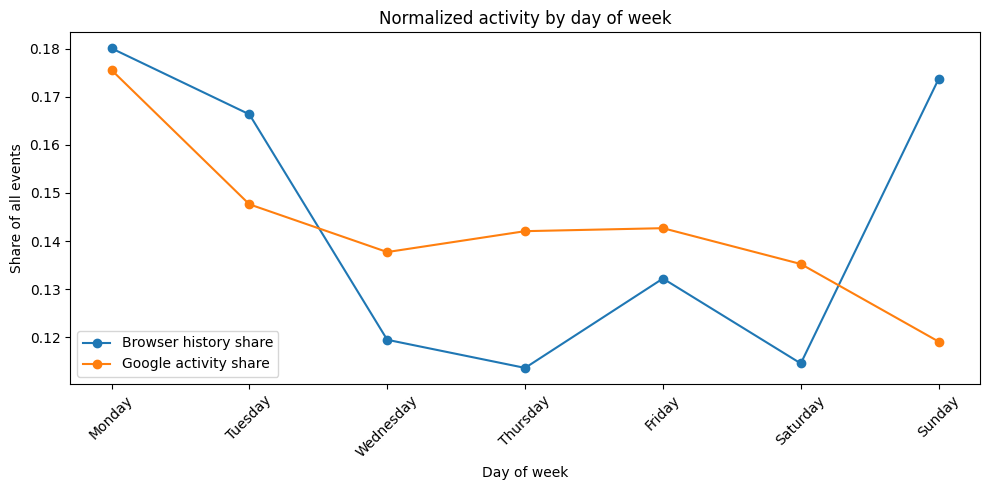

In [79]:
dow_compare["browser_share"] = dow_compare["browser_count"] / dow_compare["browser_count"].sum()
dow_compare["google_share"] = dow_compare["google_activity_count"] / dow_compare["google_activity_count"].sum()

plt.figure(figsize=(10, 5))
plt.plot(dow_compare["day_of_week_local"], dow_compare["browser_share"], marker="o", label="Browser history share")
plt.plot(dow_compare["day_of_week_local"], dow_compare["google_share"], marker="o", label="Google activity share")
plt.title("Normalized activity by day of week")
plt.xlabel("Day of week")
plt.ylabel("Share of all events")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

Explore Monthly Activity

In [80]:
hist_overlap["year_month"] = hist_overlap["datetime_local"].dt.to_period("M").astype(str)
activity_overlap["year_month"] = activity_overlap["timestamp_local"].dt.to_period("M").astype(str)

browser_monthly = (
    hist_overlap.groupby("year_month")
    .size()
    .rename("browser_count")
    .reset_index()
)

activity_monthly = (
    activity_overlap.groupby("year_month")
    .size()
    .rename("google_activity_count")
    .reset_index()
)

monthly_compare = browser_monthly.merge(activity_monthly, on="year_month", how="outer").sort_values("year_month").fillna(0)
display(monthly_compare)

C:\Users\User\AppData\Local\Temp\ipykernel_30264\3953686042.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  hist_overlap["year_month"] = hist_overlap["datetime_local"].dt.to_period("M").astype(str)
C:\Users\User\AppData\Local\Temp\ipykernel_30264\3953686042.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  activity_overlap["year_month"] = activity_overlap["timestamp_local"].dt.to_period("M").astype(str)


,year_month,browser_count,google_activity_count
0,2025-05,1831,33
1,2025-06,2751,233
2,2025-07,2814,235
3,2025-08,3027,202
4,2025-09,4469,220
5,2025-10,3105,196
6,2025-11,3184,147
7,2025-12,2153,137
8,2026-01,3789,160
9,2026-02,1944,49


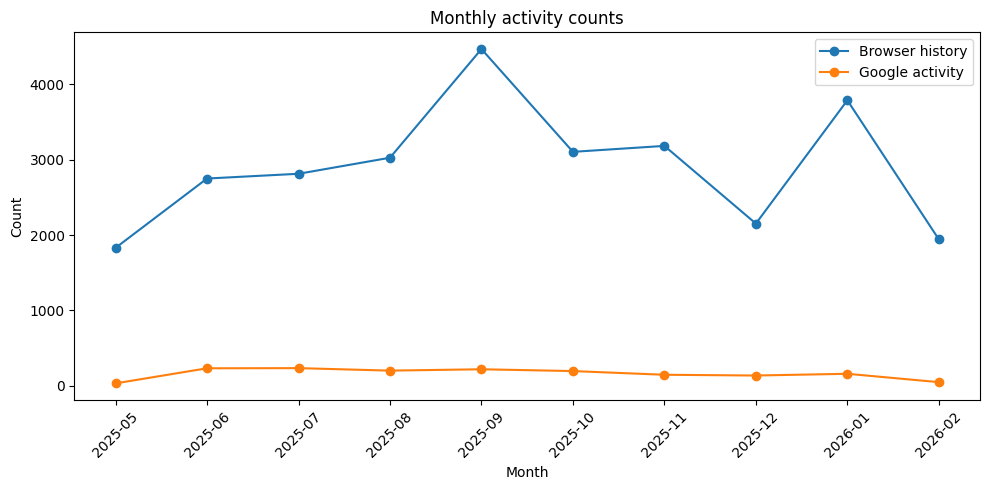

In [81]:
plt.figure(figsize=(10, 5))
plt.plot(monthly_compare["year_month"], monthly_compare["browser_count"], marker="o", label="Browser history")
plt.plot(monthly_compare["year_month"], monthly_compare["google_activity_count"], marker="o", label="Google activity")
plt.title("Monthly activity counts")
plt.xlabel("Month")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## Initial temporal findings

Browser history records direct browsing events while the Google activity table records account-related actions, therefore differences between the two are expected. Still, overlap in their temporal structure would suggest that both datasets are capturing related aspects of the same digital routine. Browser history is more robust for use as proxy data.

## Next Steps
1. Use browser history data to define "browsing sessions" based on inactivity gaps. Compute session length and pages visited per session.
2. Use browser history data to determine domain concentration and entropy
3. Carry out a sequence analysis and build domain to domain predictions